
 Grover's Algorithm Attack on a Mini-AES (4-bit) Cipher
 CS558 Quantum Cryptography Project
================================================================================

 This script implements a pedagogical 4-bit version of AES and performs a
 known-plaintext key-recovery attack using Grover's algorithm.

 STRUCTURE (matches each section to one cell if pasted into Colab):
   - Cell 1: Install dependencies
   - Cell 2: Imports
   - Cell 3: Classical Mini-AES reference implementation
   - Cell 4: Quantum building blocks for each AES step
   - Cell 5: Grover oracle (encrypt + compare + uncompute)
   - Cell 6: Grover diffusion operator
   - Cell 7: Assemble the full Grover circuit
   - Cell 8: Run on Aer simulator + measurement histogram
   - Cell 9: Visualize amplitude growth across iterations

 REFERENCES:
   - Grover (1996). A fast quantum mechanical algorithm for database search.
   - Grassl, Langenberg, Roetteler, Steinwandt (2016). Applying Grover's
     Algorithm to AES: Quantum Resource Estimates. PQCrypto 2016.
   - Preston (2022). Applying Grover's Algorithm to Hash Functions.



In [ ]:
# %% =========================================================================
# CELL 1: INSTALL DEPENDENCIES (run once per Colab session)
# =============================================================================
# Uncomment when running in Colab:
!pip install qiskit==2.4.1 qiskit-aer==0.17.2 pylatexenc matplotlib --quiet



In [ ]:
# %% =========================================================================
# CELL 2: IMPORTS
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator


In [ ]:
# %% =========================================================================
# CELL 3: CLASSICAL MINI-AES REFERENCE
# =============================================================================
# Mini-AES specification used here:
#   Block size : 4 bits (a single nibble)
#   Key size   : 4 bits
#   Rounds     : 1 (with both pre- and post-round-key whitening)
#
# Round structure (parallels FIPS-PUB 197 for full AES):
#   1. AddRoundKey   : state XOR= key
#   2. SubBytes      : 4-bit S-box (PRESENT cipher S-box)
#   3. ShiftRows     : 1-bit cyclic left rotation of the nibble
#   4. MixColumns    : in-place GF(2) linear mix
#   5. AddRoundKey   : state XOR= key
#
# Bit ordering convention: state[0] = LSB, state[3] = MSB.
# =============================================================================

# PRESENT cipher 4-bit S-box (nonlinear permutation of {0..15})
# This stands in for the AES F_256 SubBytes operation. AES's actual S-box is
# 8 bits and is built from inversion in GF(2^8) plus an affine map, which has
# no clean 4-bit analogue.
SBOX = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD,
        0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]
INV_SBOX = [SBOX.index(i) for i in range(16)]


def mini_aes_encrypt(plaintext, key):
    """Classical reference implementation. Used to compute the target
    ciphertext that Grover's oracle will check against."""
    state = plaintext ^ key                              # AddRoundKey 1
    state = SBOX[state]                                  # SubBytes
    state = ((state << 1) | (state >> 3)) & 0xF          # ShiftRows
    # MixColumns: new_b[i] = b[i] XOR b[i+1], new_b[3] = b[3]
    b = [(state >> i) & 1 for i in range(4)]
    new_b = [b[0] ^ b[1], b[1] ^ b[2], b[2] ^ b[3], b[3]]
    state = sum(new_b[i] << i for i in range(4))
    state = state ^ key                                  # AddRoundKey 2
    return state


# Set up the attack scenario
SECRET_KEY = 0x7                       # 0111 — what Grover should recover
PLAINTEXT  = 0xA                       # 1010 — known plaintext
TARGET_CT  = mini_aes_encrypt(PLAINTEXT, SECRET_KEY)

print("=" * 60)
print("CLASSICAL MINI-AES SETUP")
print("=" * 60)
print(f"  Plaintext           : 0x{PLAINTEXT:X}  ({PLAINTEXT:04b})")
print(f"  Secret key (target) : 0x{SECRET_KEY:X}  ({SECRET_KEY:04b})")
print(f"  Ciphertext          : 0x{TARGET_CT:X}  ({TARGET_CT:04b})")
print()

# Sanity check: confirm the secret key is unique among all 16 candidates
# (so Grover sees exactly one marked state). If multiple keys collide on this
# plaintext, the count M of solutions is used to set the iteration number.
matching_keys = [k for k in range(16) if mini_aes_encrypt(PLAINTEXT, k) == TARGET_CT]
print(f"  Keys mapping {PLAINTEXT:04b} -> {TARGET_CT:04b}: {matching_keys}")
print(f"  Number of solutions M = {len(matching_keys)}")
print()


CLASSICAL MINI-AES SETUP
  Plaintext           : 0xA  (1010)
  Secret key (target) : 0x7  (0111)
  Ciphertext          : 0xE  (1110)

  Keys mapping 1010 -> 1110: [7]
  Number of solutions M = 1



In [ ]:
# %% =========================================================================
# CELL 4: QUANTUM BUILDING BLOCKS FOR EACH AES STEP
# =============================================================================
# Convention:
#   key_reg[i]   = bit i of the key   (i = 0 is LSB)
#   state_reg[i] = bit i of the state (i = 0 is LSB)
# =============================================================================

def build_sbox_unitary_gate(table, label):
    """Convert a permutation table into a UnitaryGate.

    A 4-bit permutation is a 16x16 permutation matrix U where U[table[x], x]=1.
    Qiskit's transpiler will synthesize this into CX + Toffoli (CCX) gates,
    matching how Grassl et al. (2016) treat SubBytes as the T-gate-consuming
    operation in the AES quantum circuit."""
    U = np.zeros((16, 16))
    for x in range(16):
        U[table[x], x] = 1
    return UnitaryGate(U, label=label)


SBOX_GATE     = build_sbox_unitary_gate(SBOX,     "SubBytes")
INV_SBOX_GATE = build_sbox_unitary_gate(INV_SBOX, "InvSubBytes")


def add_round_key(qc, key_reg, state_reg):
    """AddRoundKey: state[i] XOR= key[i] for all i. Implemented as 4 CNOTs.

    This is the cheapest AES step in both classical and quantum settings:
    Grassl et al. show it costs 128 CNOTs per round for full AES."""
    for i in range(4):
        qc.cx(key_reg[i], state_reg[i])


def sub_bytes(qc, state_reg, inverse=False):
    """SubBytes: apply the 4-bit S-box (or its inverse).

    In full AES this is the only step that produces T-gates after Clifford+T
    decomposition. Same here: the S-box unitary contains all the nonlinearity."""
    gate = INV_SBOX_GATE if inverse else SBOX_GATE
    qc.append(gate, [state_reg[i] for i in range(4)])


def shift_rows(qc, state_reg, inverse=False):
    """ShiftRows: cyclic left rotation by 1.

    Classical effect: new_state[k] = old_state[(k-1) mod 4].
    Quantum implementation: 3 SWAP gates. These could be replaced by a
    relabeling (free, as in the Grassl paper) but explicit SWAPs make the
    circuit diagram pedagogically clearer."""
    if not inverse:
        qc.swap(state_reg[0], state_reg[3])
        qc.swap(state_reg[3], state_reg[2])
        qc.swap(state_reg[2], state_reg[1])
    else:
        qc.swap(state_reg[2], state_reg[1])
        qc.swap(state_reg[3], state_reg[2])
        qc.swap(state_reg[0], state_reg[3])


def mix_columns(qc, state_reg, inverse=False):
    """MixColumns: in-place upper-triangular GF(2) linear map.

       new_b[0] = b[0] XOR b[1]
       new_b[1] = b[1] XOR b[2]
       new_b[2] = b[2] XOR b[3]
       new_b[3] = b[3]

    Three CNOTs realize this in place. CNOT is self-inverse, so reverse-order
    of the same gates inverts the transformation."""
    if not inverse:
        qc.cx(state_reg[1], state_reg[0])
        qc.cx(state_reg[2], state_reg[1])
        qc.cx(state_reg[3], state_reg[2])
    else:
        qc.cx(state_reg[3], state_reg[2])
        qc.cx(state_reg[2], state_reg[1])
        qc.cx(state_reg[1], state_reg[0])


def mini_aes_quantum(qc, key_reg, state_reg, inverse=False):
    """Apply (or reverse) the full Mini-AES round on the given registers.

    The inverse path is required so the oracle can uncompute the state register
    back to |plaintext> after the phase kickback, leaving only the key register
    entangled with the oracle outcome. This is the same uncompute pattern shown
    in Figure 3 of Grassl, Langenberg, Roetteler, Steinwandt (2016)."""
    if not inverse:
        add_round_key(qc, key_reg, state_reg)   # Step 1
        sub_bytes(qc, state_reg)                # Step 2
        shift_rows(qc, state_reg)               # Step 3
        mix_columns(qc, state_reg)              # Step 4
        add_round_key(qc, key_reg, state_reg)   # Step 5
    else:
        add_round_key(qc, key_reg, state_reg)   # inverse of Step 5
        mix_columns(qc, state_reg, inverse=True)
        shift_rows(qc, state_reg, inverse=True)
        sub_bytes(qc, state_reg, inverse=True)
        add_round_key(qc, key_reg, state_reg)   # inverse of Step 1


# Quick correctness check: compare quantum circuit's action to classical
# reference for a fixed key and plaintext. This is a stand-alone integration
# test — never trust a quantum oracle you haven't verified classically.
def _verify_quantum_matches_classical():
    print("=" * 60)
    print("VERIFYING QUANTUM CIRCUIT MATCHES CLASSICAL MINI-AES")
    print("=" * 60)
    mismatches = 0
    for k in range(16):
        for p in range(16):
            expected = mini_aes_encrypt(p, k)
            key_reg = QuantumRegister(4, "k")
            state_reg = QuantumRegister(4, "s")
            qc = QuantumCircuit(key_reg, state_reg)
            # Initialize key and plaintext bits
            for i in range(4):
                if (k >> i) & 1: qc.x(key_reg[i])
                if (p >> i) & 1: qc.x(state_reg[i])
            mini_aes_quantum(qc, key_reg, state_reg)
            # Read out state register from statevector
            sv = Statevector.from_instruction(qc)
            # Find the basis state with amplitude 1
            idx = int(np.argmax(np.abs(sv.data)))
            # In Qiskit, qubit 0 is the least significant in the index;
            # registers are concatenated in declaration order, so the full bit
            # string is state_reg (top) | key_reg (bottom).
            bits = format(idx, f"0{qc.num_qubits}b")[::-1]  # little-endian
            state_bits = bits[4:8]
            got = int(state_bits[::-1], 2)
            if got != expected:
                mismatches += 1
    print(f"  Tested 256 (key, plaintext) pairs. Mismatches: {mismatches}")
    print()
    assert mismatches == 0, "Quantum AES diverges from classical reference"

_verify_quantum_matches_classical()


VERIFYING QUANTUM CIRCUIT MATCHES CLASSICAL MINI-AES
  Tested 256 (key, plaintext) pairs. Mismatches: 0



In [ ]:
# %% =========================================================================
# CELL 5: GROVER ORACLE
# =============================================================================
# The oracle marks the key K such that AES_K(plaintext) == target_ct by
# phase-flipping its amplitude. Pattern (also in Grover 1996, §3):
#
#   1. Prepare state register to |plaintext>
#   2. Apply AES under the superposed key -> state holds |AES_K(plaintext)>
#   3. Flip state bits so that "ciphertext match" becomes "all-ones"
#   4. MCX onto an oracle qubit held in |->: gives a phase of -1 on the match
#   5. Undo the bit-flips
#   6. Reverse AES, restoring state register to |plaintext>
#   7. Reset state register back to |0> (undo the plaintext preparation)
#
# After this sequence, only the key register carries the phase information;
# the rest of the workspace is clean and reusable for the next iteration.
# =============================================================================

def apply_oracle(qc, key_reg, state_reg, oracle_qubit, plaintext, target_ct,
                 announce=False):
    if announce:
        print("  [Oracle] preparing plaintext on state register")
    for i in range(4):
        if (plaintext >> i) & 1:
            qc.x(state_reg[i])

    if announce:
        print("  [Oracle] applying Mini-AES under superposed key")
    mini_aes_quantum(qc, key_reg, state_reg)

    if announce:
        print(f"  [Oracle] comparing ciphertext to target 0x{target_ct:X} "
              "and applying phase kickback")
    for i in range(4):
        if not ((target_ct >> i) & 1):
            qc.x(state_reg[i])
    qc.mcx([state_reg[0], state_reg[1], state_reg[2], state_reg[3]],
           oracle_qubit[0])
    for i in range(4):
        if not ((target_ct >> i) & 1):
            qc.x(state_reg[i])

    if announce:
        print("  [Oracle] uncomputing Mini-AES (inverse circuit)")
    mini_aes_quantum(qc, key_reg, state_reg, inverse=True)

    if announce:
        print("  [Oracle] resetting state register to |0>")
    for i in range(4):
        if (plaintext >> i) & 1:
            qc.x(state_reg[i])


In [ ]:
# %% =========================================================================
# CELL 6: GROVER DIFFUSION OPERATOR
# =============================================================================
# Reflection about the uniform superposition |s>. Implementation:
#   D = H^n  (2|0><0| - I)  H^n
#     = H^n  X^n  (multi-controlled-Z)  X^n  H^n
# Multi-controlled-Z on n qubits is realized as H * MCX * H on the target.
# This matches the construction in Grover's original 1997 paper (§5).
# =============================================================================

def apply_diffusion(qc, key_reg, announce=False):
    if announce:
        print("  [Diffusion] H on key register")
    qc.h(key_reg)
    if announce:
        print("  [Diffusion] X on key register")
    qc.x(key_reg)
    if announce:
        print("  [Diffusion] multi-controlled-Z about |11..1>")
    qc.h(key_reg[3])
    qc.mcx([key_reg[0], key_reg[1], key_reg[2]], key_reg[3])
    qc.h(key_reg[3])
    if announce:
        print("  [Diffusion] X on key register")
    qc.x(key_reg)
    if announce:
        print("  [Diffusion] H on key register")
    qc.h(key_reg)


In [ ]:
# %% =========================================================================
# CELL 7: ASSEMBLE THE FULL GROVER CIRCUIT
# =============================================================================

def grover_iterations_optimal(num_keys, num_solutions):
    """Boyer-Brassard-Hoyer-Tapp optimal count: floor((pi/4) * sqrt(N/M))."""
    return int(np.floor((np.pi / 4) * np.sqrt(num_keys / num_solutions)))


def build_grover_circuit(plaintext, target_ct, n_iters, verbose=True):
    key_reg     = QuantumRegister(4, name="key")
    state_reg   = QuantumRegister(4, name="state")
    oracle_qbit = QuantumRegister(1, name="oracle")
    creg        = ClassicalRegister(4, name="c")
    qc = QuantumCircuit(key_reg, state_reg, oracle_qbit, creg)

    if verbose:
        print("=" * 60)
        print(f"BUILDING GROVER CIRCUIT  (iterations = {n_iters})")
        print("=" * 60)
        print("[Init] oracle qubit -> |->")
    qc.x(oracle_qbit[0])
    qc.h(oracle_qbit[0])

    if verbose:
        print("[Init] uniform superposition on key register")
    qc.h(key_reg)
    qc.barrier()

    for it in range(n_iters):
        if verbose:
            print(f"--- Grover iteration {it + 1} / {n_iters} ---")
            print("  Applying ORACLE (phase-flip the matching key)")
        apply_oracle(qc, key_reg, state_reg, oracle_qbit,
                     plaintext, target_ct,
                     announce=(verbose and it == 0))  # sub-steps printed only once
        qc.barrier()
        if verbose:
            print("  Applying DIFFUSION (amplify amplitude of marked key)")
        apply_diffusion(qc, key_reg, announce=(verbose and it == 0))
        qc.barrier()

    if verbose:
        print("[Measure] key register -> classical register")
    qc.measure(key_reg, creg)
    return qc


N_KEYS = 16
N_SOLUTIONS = len(matching_keys)
N_ITERS = grover_iterations_optimal(N_KEYS, N_SOLUTIONS)
print(f"Optimal Grover iterations for N={N_KEYS}, M={N_SOLUTIONS}: {N_ITERS}")
print()

grover_qc = build_grover_circuit(PLAINTEXT, TARGET_CT, N_ITERS, verbose=True)

print()
print("Circuit summary:")
print(f"  Qubits          : {grover_qc.num_qubits}")
print(f"  Classical bits  : {grover_qc.num_clbits}")
print(f"  Depth (pre-tr.) : {grover_qc.depth()}")
print(f"  Gate count      : {sum(grover_qc.count_ops().values())}")
print()


Optimal Grover iterations for N=16, M=1: 3

BUILDING GROVER CIRCUIT  (iterations = 3)
[Init] oracle qubit -> |->
[Init] uniform superposition on key register
--- Grover iteration 1 / 3 ---
  Applying ORACLE (phase-flip the matching key)
  [Oracle] preparing plaintext on state register
  [Oracle] applying Mini-AES under superposed key
  [Oracle] comparing ciphertext to target 0xE and applying phase kickback
  [Oracle] uncomputing Mini-AES (inverse circuit)
  [Oracle] resetting state register to |0>
  Applying DIFFUSION (amplify amplitude of marked key)
  [Diffusion] H on key register
  [Diffusion] X on key register
  [Diffusion] multi-controlled-Z about |11..1>
  [Diffusion] X on key register
  [Diffusion] H on key register
--- Grover iteration 2 / 3 ---
  Applying ORACLE (phase-flip the matching key)
  Applying DIFFUSION (amplify amplitude of marked key)
--- Grover iteration 3 / 3 ---
  Applying ORACLE (phase-flip the matching key)
  Applying DIFFUSION (amplify amplitude of marked key)

In [ ]:
# %% =========================================================================
# CELL 8: RUN ON AER SIMULATOR AND SHOW HISTOGRAM
# =============================================================================
print("=" * 60)
print("RUNNING ON AerSimulator (statevector method)")
print("=" * 60)

simulator = AerSimulator(method="statevector")
transpiled = transpile(grover_qc, simulator, optimization_level=2)
print(f"  Transpiled depth        : {transpiled.depth()}")
print(f"  Transpiled gate count   : {sum(transpiled.count_ops().values())}")
print(f"  Transpiled basis op set : {dict(transpiled.count_ops())}")
print()

result = simulator.run(transpiled, shots=4096).result()
counts = result.get_counts()

# Pretty-print counts with the binary keys
print("Top measurement outcomes:")
for bitstring, count in sorted(counts.items(), key=lambda kv: -kv[1])[:5]:
    print(f"  |{bitstring}>  ({int(bitstring, 2):2d})  : {count} shots "
          f"({count / 4096:.1%})")
print()

target_str = format(SECRET_KEY, "04b")
hits = counts.get(target_str, 0)
print(f"Probability of recovering the secret key |{target_str}> "
      f"({SECRET_KEY}): {hits / 4096:.1%}")
print()

fig = plot_histogram(counts,
                     title=f"Grover Recovery of Mini-AES Key (target = {target_str})",
                     figsize=(10, 4))
plt.tight_layout()
plt.savefig("grover_histogram.png", dpi=140, bbox_inches="tight")
plt.show()


RUNNING ON AerSimulator (statevector method)
  Transpiled depth        : 56
  Transpiled gate count   : 136
  Transpiled basis op set : {'cx': 66, 'u2': 19, 'x': 18, 'barrier': 7, 'unitary': 6, 'mcx': 6, 'u1': 6, 'h': 4, 'measure': 4}

Top measurement outcomes:
  |0111>  ( 7)  : 3921 shots (95.7%)
  |1001>  ( 9)  : 15 shots (0.4%)
  |0101>  ( 5)  : 15 shots (0.4%)
  |1111>  (15)  : 15 shots (0.4%)
  |0110>  ( 6)  : 14 shots (0.3%)

Probability of recovering the secret key |0111> (7): 95.7%



<Figure size 640x480 with 0 Axes>

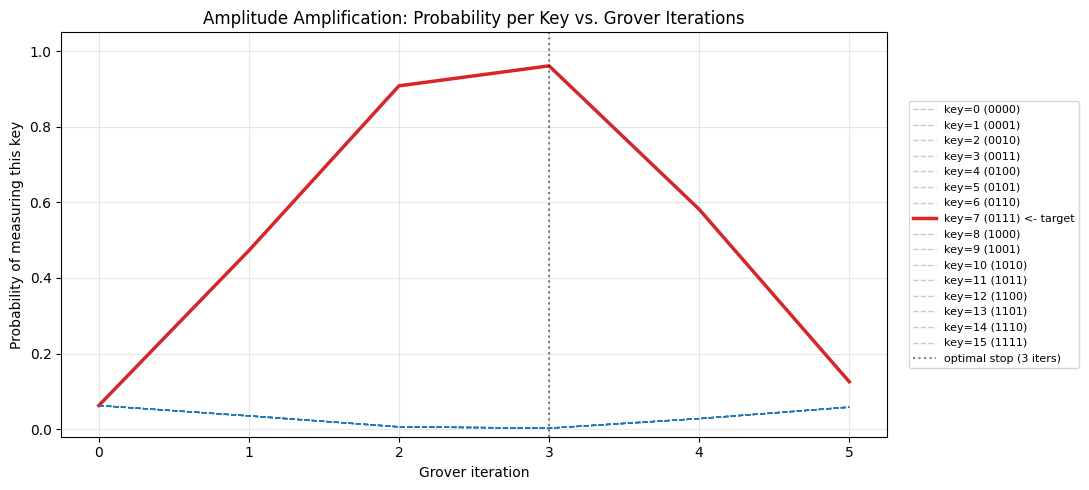

In [ ]:
# %% =========================================================================
# CELL 9: VISUALIZE AMPLITUDE GROWTH ACROSS ITERATIONS
# =============================================================================
# Build separate circuits with 0, 1, 2, ..., N_ITERS+2 Grover iterations and
# read the statevector after each. Track the probability mass on each of the
# 16 candidate keys. This is the same picture as Figure 2 in Grover (1997):
# inversion about the average gradually amplifies the marked state.
# =============================================================================

def amplitudes_per_iteration(plaintext, target_ct, max_iters):
    probs_per_iter = []
    for n in range(max_iters + 1):
        key_reg     = QuantumRegister(4, name="key")
        state_reg   = QuantumRegister(4, name="state")
        oracle_qbit = QuantumRegister(1, name="oracle")
        qc = QuantumCircuit(key_reg, state_reg, oracle_qbit)
        qc.x(oracle_qbit[0])
        qc.h(oracle_qbit[0])
        qc.h(key_reg)
        for _ in range(n):
            apply_oracle(qc, key_reg, state_reg, oracle_qbit,
                         plaintext, target_ct, announce=False)
            apply_diffusion(qc, key_reg, announce=False)

        sv = Statevector.from_instruction(qc)
        # Marginalize over state_reg and oracle_qbit to get probability per key.
        # Qubit layout (little-endian basis index): key[0..3], state[0..3], oracle.
        probs = np.zeros(16)
        for idx, amp in enumerate(sv.data):
            key_bits = idx & 0xF              # low 4 bits index = key bits
            probs[key_bits] += float(np.abs(amp) ** 2)
        probs_per_iter.append(probs)
    return np.array(probs_per_iter)


MAX_PLOT_ITERS = max(N_ITERS + 2, 5)
prob_grid = amplitudes_per_iteration(PLAINTEXT, TARGET_CT, MAX_PLOT_ITERS)

fig, ax = plt.subplots(figsize=(11, 5))
colors = ["#d62728" if k == SECRET_KEY else "#1f77b4" for k in range(16)]
for k in range(16):
    style = "-" if k == SECRET_KEY else "--"
    alpha = 1.0 if k == SECRET_KEY else 0.35
    lw = 2.5 if k == SECRET_KEY else 1
    ax.plot(prob_grid[:, k], style, color=colors[k], alpha=alpha, lw=lw,
            label=f"key={k} ({k:04b})" + (" <- target" if k == SECRET_KEY else ""))
ax.axvline(N_ITERS, color="k", linestyle=":", alpha=0.5,
           label=f"optimal stop ({N_ITERS} iters)")
ax.set_xlabel("Grover iteration")
ax.set_ylabel("Probability of measuring this key")
ax.set_title("Amplitude Amplification: Probability per Key vs. Grover Iterations")
ax.set_ylim(-0.02, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, ncol=1)
plt.tight_layout()
plt.savefig("grover_amplitudes.png", dpi=140, bbox_inches="tight")
plt.show()


In [ ]:
# %% =========================================================================
# CELL 10 (optional): DRAW THE ORACLE AND ONE FULL GROVER ITERATION
# =============================================================================
# Build a one-iteration version of the circuit (no measurement) for diagramming.
viz_key   = QuantumRegister(4, name="key")
viz_state = QuantumRegister(4, name="state")
viz_oracle = QuantumRegister(1, name="oracle")
viz_qc = QuantumCircuit(viz_key, viz_state, viz_oracle)
viz_qc.x(viz_oracle[0]); viz_qc.h(viz_oracle[0])
viz_qc.h(viz_key)
viz_qc.barrier()
apply_oracle(viz_qc, viz_key, viz_state, viz_oracle, PLAINTEXT, TARGET_CT)
viz_qc.barrier()
apply_diffusion(viz_qc, viz_key)
print("One full Grover iteration (oracle + diffusion):")
print(viz_qc.draw(output="text", fold=120))

One full Grover iteration (oracle + diffusion):
         ┌───┐      ░                                                                                                  »
  key_0: ┤ H ├──────░───■──────────────────────────────────────────────■───────────────────────────────────────────────»
         ├───┤      ░   │                                              │                                               »
  key_1: ┤ H ├──────░───┼─────────■────────────────────────────────────┼────■─────────────────────────────■────────────»
         ├───┤      ░   │         │                                    │    │                             │            »
  key_2: ┤ H ├──────░───┼────■────┼────────────────────────────────────┼────┼─────────■───────────────────┼────■───────»
         ├───┤      ░   │    │    │                                    │    │         │                   │    │       »
  key_3: ┤ H ├──────░───┼────┼────┼────■───────────────────────────────┼────┼─────────┼────■─────────────

# Figure Generators for Report

In [ ]:
# %% =========================================================================
# CELL A: IMPORTS  (only needed if running standalone after a kernel reset)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# These are assumed to exist from grover_mini_aes.py:
#   SECRET_KEY, PLAINTEXT, TARGET_CT
#   build_grover_circuit, apply_oracle, apply_diffusion
#   N_ITERS  (optimal Grover iteration count, = 3 for this setup)
#
# If anything is missing, re-run grover_mini_aes.py in a previous cell.


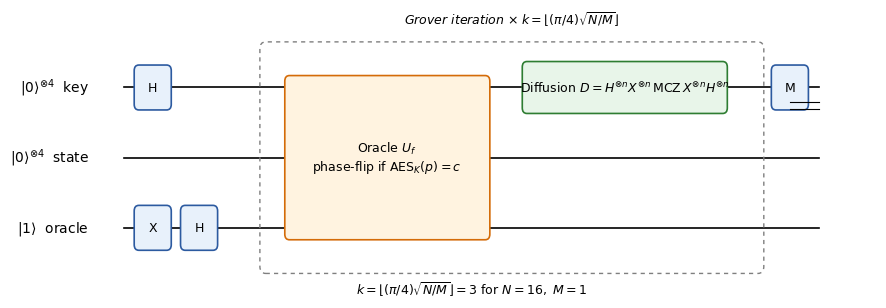

[FIG 1] saved to fig1_grover_circuit_schematic.pdf


In [ ]:
# %% =========================================================================
# CELL B: FIGURE 1 -- High-level Grover circuit schematic (block diagram)
# =============================================================================
# This is a hand-drawn schematic, not a Qiskit-rendered circuit. The Qiskit
# output of the full circuit is cluttered by S-box decomposition. A block
# diagram communicates the algorithm structure better in a paper.
# =============================================================================

def draw_grover_schematic(savepath="fig1_grover_circuit_schematic.pdf"):
    fig, ax = plt.subplots(figsize=(9, 3.2))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 4)
    ax.axis("off")

    # Horizontal qubit wires
    wire_y = {"key": 3.0, "state": 2.0, "oracle": 1.0}
    wire_labels = {
        "key": r"$|0\rangle^{\otimes 4}$  key",
        "state": r"$|0\rangle^{\otimes 4}$  state",
        "oracle": r"$|1\rangle$  oracle",
    }
    for name, y in wire_y.items():
        ax.plot([1.0, 13.0], [y, y], color="black", lw=1.2, zorder=1)
        ax.text(0.4, y, wire_labels[name], ha="right", va="center", fontsize=10)

    def box(x, y, w, h, label, color="#e8f1fb", edge="#2c5aa0"):
        patch = FancyBboxPatch(
            (x, y - h / 2), w, h,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            linewidth=1.2, edgecolor=edge, facecolor=color
        )
        ax.add_patch(patch)
        ax.text(x + w / 2, y, label, ha="center", va="center", fontsize=9, zorder=3)

    # Initial Hadamards on key register
    box(1.2, 3.0, 0.6, 0.6, "H")
    # X then H on oracle qubit
    box(1.2, 1.0, 0.6, 0.6, "X")
    box(2.0, 1.0, 0.6, 0.6, "H")

    # Grover iteration block (drawn once with a "x k" multiplier)
    iter_x0 = 3.4
    iter_w = 8.6
    # outer dashed box
    outer = FancyBboxPatch(
        (iter_x0, 0.4), iter_w, 3.2,
        boxstyle="round,pad=0.05,rounding_size=0.10",
        linewidth=1.0, edgecolor="#7f7f7f",
        facecolor="none", linestyle=(0, (3, 3))
    )
    ax.add_patch(outer)
    ax.text(iter_x0 + iter_w / 2, 3.85,
            r"Grover iteration $\times\;k=\lfloor(\pi/4)\sqrt{N/M}\rfloor$",
            ha="center", va="bottom", fontsize=9, style="italic")

    # Oracle block (spans all three wires)
    oracle_x = iter_x0 + 0.4
    oracle_w = 3.5
    box(oracle_x, 2.0, oracle_w, 2.3,
        r"Oracle $U_f$" + "\n" + r"phase-flip if AES$_K(p)=c$",
        color="#fff3e0", edge="#d46b08")

    # Diffusion block (spans key register only)
    diff_x = oracle_x + oracle_w + 0.6
    diff_w = 3.5
    box(diff_x, 3.0, diff_w, 0.7,
        r"Diffusion $D=H^{\otimes n}X^{\otimes n}\,\mathrm{MCZ}\,X^{\otimes n}H^{\otimes n}$",
        color="#e8f5e9", edge="#2e7d32")

    # Measurement on key register
    box(12.2, 3.0, 0.6, 0.6, "M")
    # double-line for classical wire
    ax.plot([12.5, 13.0], [2.8, 2.8], color="black", lw=0.8)
    ax.plot([12.5, 13.0], [2.7, 2.7], color="black", lw=0.8)

    # Caption-like annotation
    ax.text(7.0, 0.0,
            r"$k = \lfloor(\pi/4)\sqrt{N/M}\rfloor = 3$ for $N=16,\ M=1$",
            ha="center", va="bottom", fontsize=9)

    plt.tight_layout()
    plt.savefig(savepath, bbox_inches="tight")
    plt.show()
    print(f"[FIG 1] saved to {savepath}")


draw_grover_schematic()


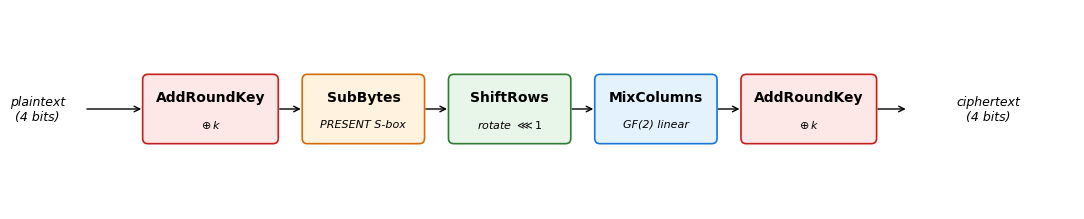

[FIG 2] saved to fig2_mini_aes_round.pdf


In [ ]:
# %% =========================================================================
# CELL C: FIGURE 2 -- Mini-AES round structure (block diagram)
# =============================================================================

def draw_mini_aes_round(savepath="fig2_mini_aes_round.pdf"):
    fig, ax = plt.subplots(figsize=(11, 2.3))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 3)
    ax.axis("off")

    def block(x, y, w, h, title, sub=None, color="#e8f1fb", edge="#2c5aa0"):
        patch = FancyBboxPatch(
            (x, y - h / 2), w, h,
            boxstyle="round,pad=0.02,rounding_size=0.08",
            linewidth=1.2, edgecolor=edge, facecolor=color
        )
        ax.add_patch(patch)
        ax.text(x + w / 2, y + 0.18 if sub else y, title,
                ha="center", va="center", fontsize=10, weight="bold")
        if sub:
            ax.text(x + w / 2, y - 0.22, sub,
                    ha="center", va="center", fontsize=8, style="italic")

    def arrow(x_from, x_to, y=1.5):
        ax.annotate(
            "", xy=(x_to, y), xytext=(x_from, y),
            arrowprops=dict(arrowstyle="->", lw=1.0, color="black")
        )

    # Plaintext input
    ax.text(0.4, 1.5, "plaintext\n(4 bits)", ha="center", va="center",
            fontsize=9, style="italic")
    arrow(1.1, 2.0)

    # AddRoundKey 1
    block(2.0, 1.5, 2.0, 1.0, "AddRoundKey", r"$\oplus\,k$",
          color="#fde7e7", edge="#c41e1e")
    arrow(4.0, 4.4)

    # SubBytes
    block(4.4, 1.5, 1.8, 1.0, "SubBytes", "PRESENT S-box",
          color="#fff3e0", edge="#d46b08")
    arrow(6.2, 6.6)

    # ShiftRows
    block(6.6, 1.5, 1.8, 1.0, "ShiftRows", r"rotate $\lll 1$",
          color="#e8f5e9", edge="#2e7d32")
    arrow(8.4, 8.8)

    # MixColumns
    block(8.8, 1.5, 1.8, 1.0, "MixColumns", r"GF(2) linear",
          color="#e3f2fd", edge="#1976d2")
    arrow(10.6, 11.0)

    # AddRoundKey 2
    block(11.0, 1.5, 2.0, 1.0, "AddRoundKey", r"$\oplus\,k$",
          color="#fde7e7", edge="#c41e1e")
    arrow(13.0, 13.5)

    # Ciphertext output
    ax.text(14.7, 1.5, "ciphertext\n(4 bits)", ha="center", va="center",
            fontsize=9, style="italic")

    plt.tight_layout()
    plt.savefig(savepath, bbox_inches="tight")
    plt.show()
    print(f"[FIG 2] saved to {savepath}")


draw_mini_aes_round()


MULTI-TRIAL GROVER  (trials=10, shots/trial=4096)
  trial  1/10: success rate = 0.9590
  trial  2/10: success rate = 0.9634
  trial  3/10: success rate = 0.9602
  trial  4/10: success rate = 0.9583
  trial  5/10: success rate = 0.9575
  trial  6/10: success rate = 0.9612
  trial  7/10: success rate = 0.9553
  trial  8/10: success rate = 0.9609
  trial  9/10: success rate = 0.9622
  trial 10/10: success rate = 0.9546

  mean success rate : 0.9593
  std  success rate : 0.0029
  total shots       : 40960



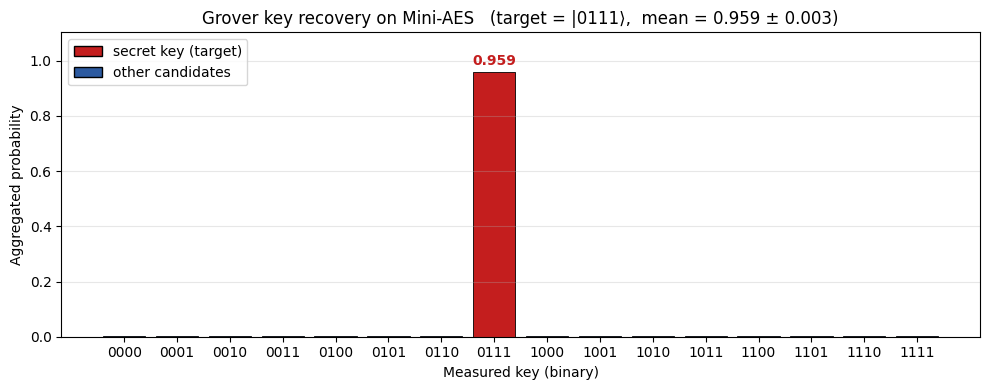

[FIG 3] saved to fig3_grover_histogram.{pdf,png}


In [ ]:
# %% =========================================================================
# CELL D: FIGURE 3 -- Multi-trial histogram of Grover measurement outcomes
# =============================================================================
# What this does:
#   - Runs the full Grover circuit construction N_TRIALS times.
#   - Each run uses N_SHOTS shots on the Aer simulator.
#   - Aggregates counts across all trials and reports the mean and std of the
#     per-trial success rate (the probability of measuring the secret key).
#   - Plots the aggregated histogram.
#
# A single trial of N_SHOTS is already statistically tight; running multiple
# trials demonstrates simulator determinism and gives a defensible error bar.
# =============================================================================

N_TRIALS = 10
N_SHOTS  = 4096

def run_grover_trial(plaintext, target_ct, n_iters, shots):
    qc = build_grover_circuit(plaintext, target_ct, n_iters, verbose=False)
    simulator = AerSimulator(method="statevector")
    transpiled = transpile(qc, simulator, optimization_level=2)
    result = simulator.run(transpiled, shots=shots).result()
    return result.get_counts()


print("=" * 60)
print(f"MULTI-TRIAL GROVER  (trials={N_TRIALS}, shots/trial={N_SHOTS})")
print("=" * 60)

target_bitstring = format(SECRET_KEY, "04b")
per_trial_success = []
aggregated = {format(k, "04b"): 0 for k in range(16)}

for t in range(N_TRIALS):
    counts = run_grover_trial(PLAINTEXT, TARGET_CT, N_ITERS, N_SHOTS)
    hits = counts.get(target_bitstring, 0)
    rate = hits / N_SHOTS
    per_trial_success.append(rate)
    for bits, n in counts.items():
        aggregated[bits] = aggregated.get(bits, 0) + n
    print(f"  trial {t + 1:2d}/{N_TRIALS}: success rate = {rate:.4f}")

mean_rate = float(np.mean(per_trial_success))
std_rate  = float(np.std(per_trial_success, ddof=1))
print()
print(f"  mean success rate : {mean_rate:.4f}")
print(f"  std  success rate : {std_rate:.4f}")
print(f"  total shots       : {N_TRIALS * N_SHOTS}")
print()

# Plot the aggregated histogram
keys_sorted = [format(k, "04b") for k in range(16)]
values      = [aggregated.get(k, 0) for k in keys_sorted]
total_shots = sum(values)
probs       = [v / total_shots for v in values]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#c41e1e" if k == target_bitstring else "#2c5aa0" for k in keys_sorted]
bars = ax.bar(keys_sorted, probs, color=colors, edgecolor="black", linewidth=0.6)

# Annotate the marked bar
target_idx = int(SECRET_KEY)
ax.text(target_idx, probs[target_idx] + 0.015,
        f"{probs[target_idx]:.3f}",
        ha="center", va="bottom", fontsize=10, weight="bold", color="#c41e1e")

ax.set_xlabel("Measured key (binary)")
ax.set_ylabel("Aggregated probability")
ax.set_title(
    f"Grover key recovery on Mini-AES   "
    f"(target = |{target_bitstring}\u27E9,  "
    f"mean = {mean_rate:.3f} \u00B1 {std_rate:.3f})"
)
ax.set_ylim(0, max(probs) * 1.15)
ax.grid(True, axis="y", alpha=0.3)

# Legend
ax.legend(handles=[
    mpatches.Patch(facecolor="#c41e1e", edgecolor="black", label="secret key (target)"),
    mpatches.Patch(facecolor="#2c5aa0", edgecolor="black", label="other candidates"),
], loc="upper left")

plt.tight_layout()
plt.savefig("fig3_grover_histogram.pdf", bbox_inches="tight")
plt.savefig("fig3_grover_histogram.png", dpi=200, bbox_inches="tight")
plt.show()
print("[FIG 3] saved to fig3_grover_histogram.{pdf,png}")


AMPLITUDE TRAJECTORY  (iterations 0..7)
  iter 0: P(secret)=0.0625, P(others avg)=0.0625
  iter 1: P(secret)=0.4727, P(others avg)=0.0352
  iter 2: P(secret)=0.9084, P(others avg)=0.0061
  iter 3: P(secret)=0.9613, P(others avg)=0.0026
  iter 4: P(secret)=0.5817, P(others avg)=0.0279
  iter 5: P(secret)=0.1255, P(others avg)=0.0583
  iter 6: P(secret)=0.0204, P(others avg)=0.0653
  iter 7: P(secret)=0.3649, P(others avg)=0.0423



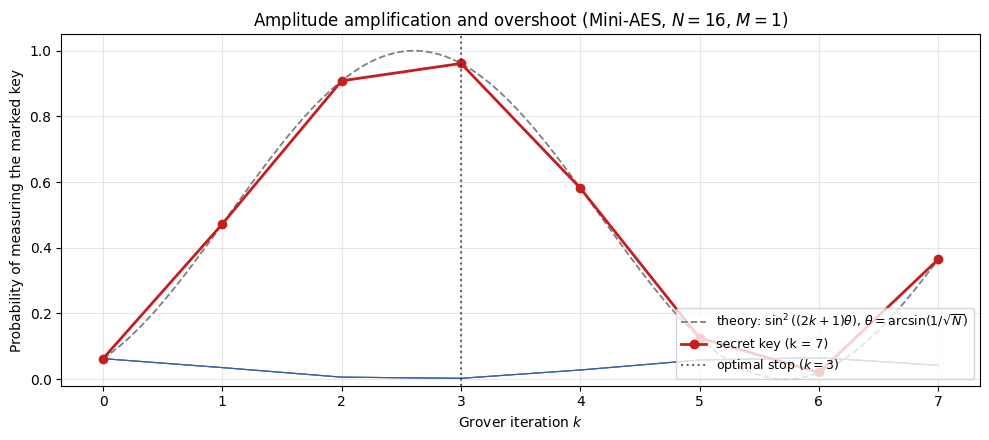

[FIG 4] saved to fig4_grover_amplitudes.{pdf,png}


In [ ]:
# %% =========================================================================
# CELL E: FIGURE 4 -- Extended amplitude amplification with Grover overshoot
# =============================================================================
# The per-iteration probability is computed analytically from the statevector.
# Extending past the optimal stopping point (k=3) shows the characteristic
# overshoot: the marked state's probability oscillates back down at k=4,5,...
# This is exactly the rotation in the |good>-|bad> plane predicted by theory.
# =============================================================================

MAX_ITERS_EXTENDED = 7  # well past optimal to show overshoot

def amplitudes_per_iteration_extended(plaintext, target_ct, max_iters):
    rows = []
    for n in range(max_iters + 1):
        key_reg     = QuantumRegister(4, name="key")
        state_reg   = QuantumRegister(4, name="state")
        oracle_qbit = QuantumRegister(1, name="oracle")
        qc = QuantumCircuit(key_reg, state_reg, oracle_qbit)
        qc.x(oracle_qbit[0])
        qc.h(oracle_qbit[0])
        qc.h(key_reg)
        for _ in range(n):
            apply_oracle(qc, key_reg, state_reg, oracle_qbit,
                         plaintext, target_ct, announce=False)
            apply_diffusion(qc, key_reg, announce=False)
        sv = Statevector.from_instruction(qc)
        probs = np.zeros(16)
        for idx, amp in enumerate(sv.data):
            key_bits = idx & 0xF
            probs[key_bits] += float(np.abs(amp) ** 2)
        rows.append(probs)
    return np.array(rows)


print("=" * 60)
print(f"AMPLITUDE TRAJECTORY  (iterations 0..{MAX_ITERS_EXTENDED})")
print("=" * 60)
prob_grid = amplitudes_per_iteration_extended(PLAINTEXT, TARGET_CT,
                                              MAX_ITERS_EXTENDED)
for i, row in enumerate(prob_grid):
    print(f"  iter {i}: P(secret)={row[SECRET_KEY]:.4f}, "
          f"P(others avg)={np.mean(np.delete(row, SECRET_KEY)):.4f}")
print()

# Theoretical curve sin^2((2k+1)theta) with theta = arcsin(1/sqrt(N))
N = 16
theta = np.arcsin(1.0 / np.sqrt(N))
k_grid = np.linspace(0, MAX_ITERS_EXTENDED, 200)
p_theory = np.sin((2 * k_grid + 1) * theta) ** 2

fig, ax = plt.subplots(figsize=(10, 4.5))
# Other keys (background)
for k in range(16):
    if k == SECRET_KEY:
        continue
    ax.plot(range(MAX_ITERS_EXTENDED + 1), prob_grid[:, k],
            color="#2c5aa0", alpha=0.18, lw=0.8)
# Theoretical curve
ax.plot(k_grid, p_theory, color="#7f7f7f", ls="--", lw=1.3,
        label=r"theory: $\sin^2((2k+1)\theta)$, $\theta=\arcsin(1/\sqrt{N})$")
# Marked key (target) trajectory
ax.plot(range(MAX_ITERS_EXTENDED + 1), prob_grid[:, SECRET_KEY],
        color="#c41e1e", marker="o", lw=2.0, label=f"secret key (k = {SECRET_KEY})")
# Optimal stopping marker
ax.axvline(N_ITERS, color="black", ls=":", alpha=0.6,
           label=f"optimal stop ($k={N_ITERS}$)")

ax.set_xlabel("Grover iteration $k$")
ax.set_ylabel("Probability of measuring the marked key")
ax.set_title("Amplitude amplification and overshoot (Mini-AES, $N=16$, $M=1$)")
ax.set_xticks(range(MAX_ITERS_EXTENDED + 1))
ax.set_ylim(-0.02, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("fig4_grover_amplitudes.pdf", bbox_inches="tight")
plt.savefig("fig4_grover_amplitudes.png", dpi=200, bbox_inches="tight")
plt.show()
print("[FIG 4] saved to fig4_grover_amplitudes.{pdf,png}")


In [ ]:
# %% =========================================================================
# CELL F (optional): Detailed Qiskit-rendered circuit for one Grover iteration
# =============================================================================
# This is what the actual circuit looks like at the gate level. Useful as an
# appendix figure or for a slide deck; usually too cluttered for a main figure.
# =============================================================================

key_reg     = QuantumRegister(4, name="key")
state_reg   = QuantumRegister(4, name="state")
oracle_qbit = QuantumRegister(1, name="oracle")
viz_qc = QuantumCircuit(key_reg, state_reg, oracle_qbit)
viz_qc.x(oracle_qbit[0]); viz_qc.h(oracle_qbit[0])
viz_qc.h(key_reg)
viz_qc.barrier()
apply_oracle(viz_qc, key_reg, state_reg, oracle_qbit, PLAINTEXT, TARGET_CT)
viz_qc.barrier(label="diffusion")
apply_diffusion(viz_qc, key_reg)

fig = viz_qc.draw(output="mpl", fold=80, style="iqp")
fig.savefig("fig_appendix_full_circuit.pdf", bbox_inches="tight")
fig.savefig("fig_appendix_full_circuit.png", dpi=160, bbox_inches="tight")
print("[APPENDIX] saved to fig_appendix_full_circuit.{pdf,png}")


[APPENDIX] saved to fig_appendix_full_circuit.{pdf,png}
